In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [6]:
df["Exited"].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


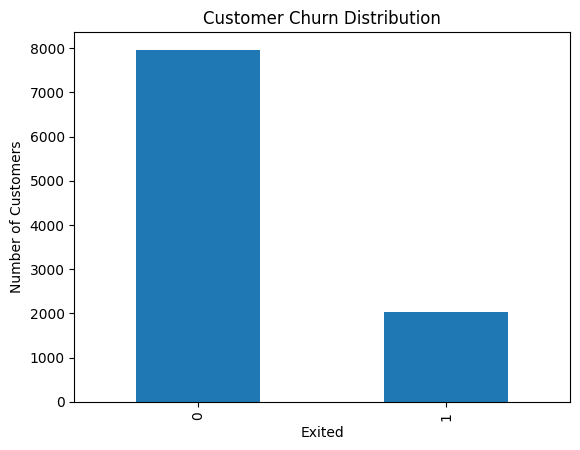

In [8]:
df["Exited"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

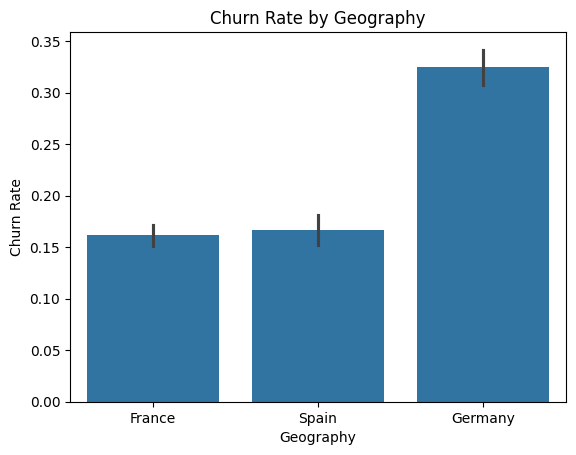

In [9]:
sns.barplot(
    data=df,
    x="Geography",
    y="Exited"
)

plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.show()

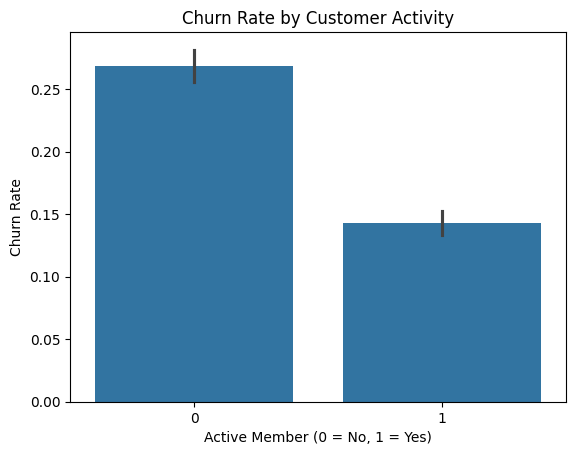

In [10]:
sns.barplot(
    data=df,
    x="IsActiveMember",
    y="Exited"
)

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")
plt.show()

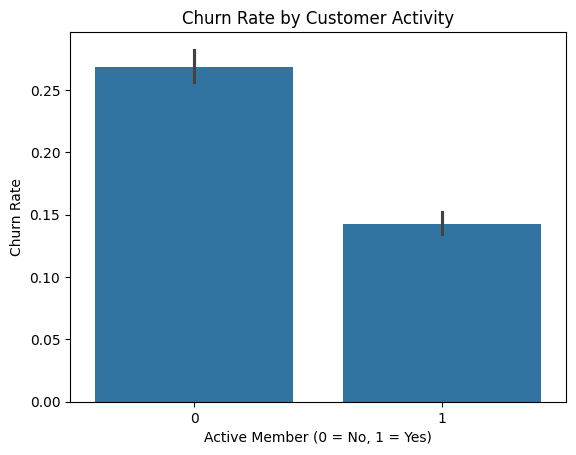

In [11]:
sns.barplot(
    data=df,
    x="IsActiveMember",
    y="Exited"
)

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")
plt.show()

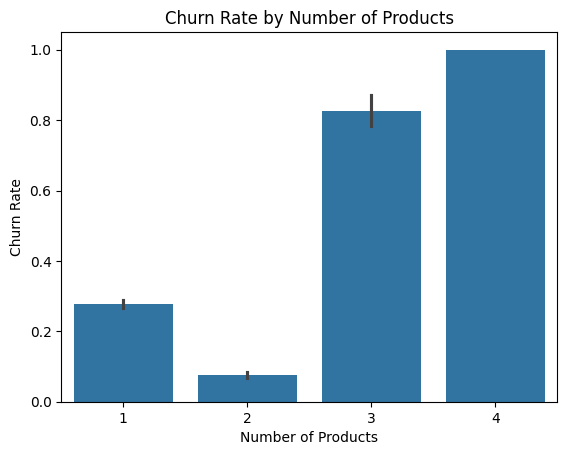

In [12]:
sns.barplot(
    data=df,
    x="NumOfProducts",
    y="Exited"
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.show()

In [13]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [14]:
df_model = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
X = df_model.drop("Exited", axis=1)

In [16]:
y = df_model["Exited"]

In [17]:
X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [19]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training: (8000, 11)
Testing: (2000, 11)

Training churn rate: 0.20375
Testing churn rate: 0.2035


In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [25]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [26]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.808


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



[[1540   53]
 [ 331   76]]


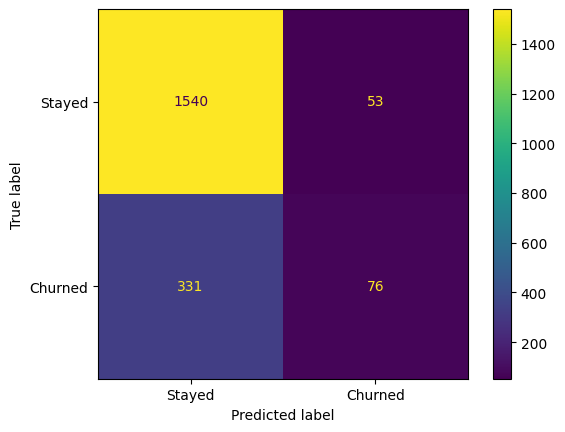

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.7748


In [34]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.7748


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [36]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, rf_pred))

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", round(rf_auc, 4))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Random Forest ROC-AUC: 0.8549


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    pred = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.20 | Precision: 0.47 | Recall: 0.78 | F1: 0.59
Threshold: 0.25 | Precision: 0.52 | Recall: 0.71 | F1: 0.60
Threshold: 0.30 | Precision: 0.60 | Recall: 0.65 | F1: 0.63
Threshold: 0.35 | Precision: 0.64 | Recall: 0.58 | F1: 0.61
Threshold: 0.40 | Precision: 0.70 | Recall: 0.54 | F1: 0.61
Threshold: 0.45 | Precision: 0.75 | Recall: 0.50 | F1: 0.60
Threshold: 0.50 | Precision: 0.78 | Recall: 0.45 | F1: 0.57


In [38]:
threshold = 0.30

risk_flag = (rf_prob >= threshold).astype(int)

print("Customers flagged:", risk_flag.sum())
print("Total customers:", len(risk_flag))
print("Percentage flagged:", round(risk_flag.mean() * 100, 2), "%")

Customers flagged: 443
Total customers: 2000
Percentage flagged: 22.15 %


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
1                 Age    0.251895
3             Balance    0.142469
7     EstimatedSalary    0.137928
0         CreditScore    0.133950
4       NumOfProducts    0.130947
2              Tenure    0.079861
6      IsActiveMember    0.036486
8   Geography_Germany    0.033254
10        Gender_Male    0.020249
5           HasCrCard    0.018219
9     Geography_Spain    0.014742


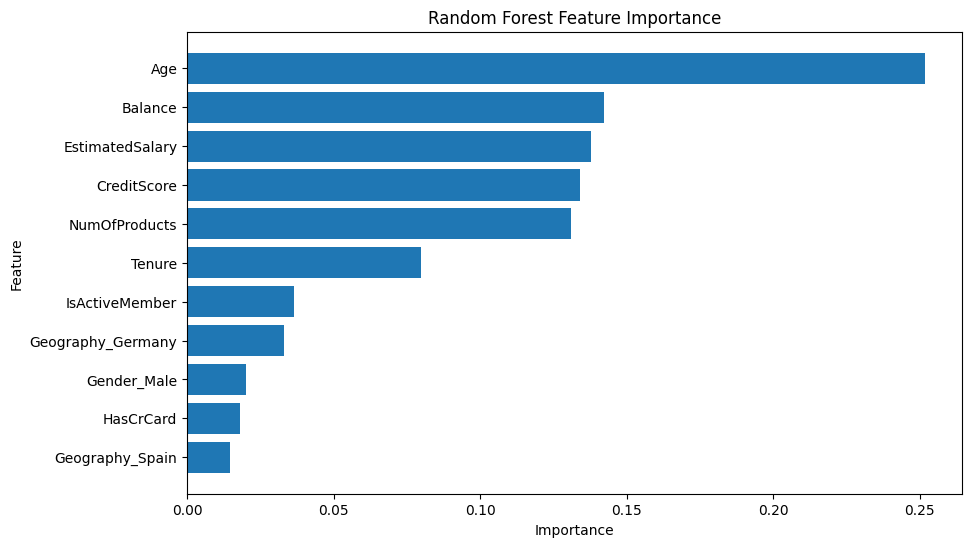

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [41]:
results = X_test.copy()

results["Actual_Churn"] = y_test.values
results["Churn_Probability"] = rf_prob

results["Risk_Level"] = pd.cut(
    results["Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

results.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Actual_Churn,Churn_Probability,Risk_Level
5702,585,36,7,0.00,2,1,0,94283.09,False,False,True,0,0.053333,Low
3667,525,33,4,131023.76,2,0,0,55072.93,True,False,True,0,0.046667,Low
1617,557,40,4,0.00,2,0,1,105433.53,False,True,False,0,0.106667,Low
5673,639,34,5,139393.19,2,0,0,33950.08,False,True,True,0,0.013333,Low
4272,640,34,3,77826.80,1,1,1,168544.85,False,True,False,0,0.070000,Low


In [42]:
results = df.loc[X_test.index].copy()

results["Churn_Probability"] = rf_prob

results["Risk_Level"] = pd.cut(
    results["Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

results.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Probability,Risk_Level
5702,5703,15749540,Hsiung,585,France,Male,36,7,0.00,2,1,0,94283.09,0,0.053333,Low
3667,3668,15807340,O'Donnell,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,0,0.046667,Low
1617,1618,15801062,Matthews,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0,0.106667,Low
5673,5674,15572801,Krischock,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,0,0.013333,Low
4272,4273,15600708,Calabresi,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0,0.070000,Low


In [43]:
print(results["Risk_Level"].value_counts())

Risk_Level
Low       1560
Medium     274
High       166
Name: count, dtype: int64


In [44]:
results["Predicted_Churn"] = (
    results["Churn_Probability"] >= 0.30
).astype(int)

results[[
    "CustomerId",
    "Geography",
    "Age",
    "NumOfProducts",
    "IsActiveMember",
    "Churn_Probability",
    "Risk_Level",
    "Predicted_Churn",
    "Exited"
]].head()

,CustomerId,Geography,Age,NumOfProducts,IsActiveMember,Churn_Probability,Risk_Level,Predicted_Churn,Exited
5702,15749540,France,36,2,0,0.053333,Low,0,0
3667,15807340,Germany,33,2,0,0.046667,Low,0,0
1617,15801062,Spain,40,2,1,0.106667,Low,0,0
5673,15572801,Spain,34,2,0,0.013333,Low,0,0
4272,15600708,Spain,34,1,1,0.070000,Low,0,0


In [45]:
print("Predicted churn:", results["Predicted_Churn"].sum())
print("Actual churn:", results["Exited"].sum())

print("\nRisk level:")
print(results["Risk_Level"].value_counts())

Predicted churn: 443
Actual churn: 407

Risk level:
Risk_Level
Low       1560
Medium     274
High       166
Name: count, dtype: int64


In [46]:
print(
    pd.crosstab(
        results["Risk_Level"],
        results["Exited"],
        margins=True
    )
)

Exited         0    1   All
Risk_Level                 
Low         1418  142  1560
Medium       150  124   274
High          25  141   166
All         1593  407  2000


In [47]:
model_predictions = results.copy()

model_predictions.to_csv(
    "model_predictions.csv",
    index=False
)

print("Saved:", len(model_predictions), "customers")

Saved: 2000 customers
